# Monte Carlo Control: learn action values from complete episodes

Monte Carlo control averages returns following visited state-action pairs:

$$G_t=\sum_{k=t}^{T-1}\gamma^{k-t}R_{k+1},\qquad
Q(S_t,A_t)\leftarrow Q(S_t,A_t)+\frac{G_t-Q(S_t,A_t)}{N(S_t,A_t)}.$$

Here $G_t$ is the complete discounted return, $T$ the episode length, $\gamma$ the discount factor, and $N(s,a)$ the visit count. An epsilon-greedy behavior policy improves as these estimates change.

In [1]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

ENV_ID = "FrozenLake-v1"
TOTAL_TIMESTEPS = 10_000
GAMMA = 0.99
EPSILON_START = 1.0
EPSILON_END = 0.05
EXPLORATION_STEPS = 6_000
SEED = 7

env = gym.make(ENV_ID, is_slippery=False)
rng = np.random.default_rng(SEED)
q_table = np.zeros((env.observation_space.n, env.action_space.n))
visit_counts = np.zeros_like(q_table, dtype=np.int64)

## 1. Generate episodes with epsilon-greedy behavior

Exploration decays linearly with environment steps. Evaluation later uses the greedy branch only.

In [2]:
def epsilon_at(step):
    fraction = min(step / EXPLORATION_STEPS, 1.0)
    return EPSILON_START + fraction * (EPSILON_END - EPSILON_START)


def select_action(state, step, deterministic=False):
    if not deterministic and rng.random() < epsilon_at(step):
        return int(rng.integers(q_table.shape[1]))
    return int(np.argmax(q_table[state]))


def collect_episode(step):
    trajectory = []
    state, _ = env.reset()
    done = False
    while not done:
        action = select_action(state, step + len(trajectory))
        next_state, reward, terminated, truncated, _ = env.step(action)
        trajectory.append((state, action, reward))
        state = next_state
        done = terminated or truncated
    return trajectory

## 2. Apply first-visit return updates

Walk backward once to compute every $G_t$, then update only the first occurrence of each pair. Monte Carlo uses no bootstrap; both `terminated` and `truncated` therefore define the sampled return boundary.

In [3]:
def update_from_episode(trajectory):
    returns = np.zeros(len(trajectory))
    reward_to_go = 0.0
    for index in reversed(range(len(trajectory))):
        reward_to_go = trajectory[index][2] + GAMMA * reward_to_go
        returns[index] = reward_to_go

    seen = set()
    for index, (state, action, _) in enumerate(trajectory):
        if (state, action) in seen:
            continue
        seen.add((state, action))
        visit_counts[state, action] += 1
        q_table[state, action] += (
            returns[index] - q_table[state, action]
        ) / visit_counts[state, action]


def train(total_timesteps):
    episode_returns = []
    steps = 0
    while steps < total_timesteps:
        trajectory = collect_episode(steps)
        update_from_episode(trajectory)
        steps += len(trajectory)
        episode_returns.append(sum(item[2] for item in trajectory))
    return episode_returns


episode_returns = train(TOTAL_TIMESTEPS)
env.close()

## 3. Plot learning

Individual returns are binary on FrozenLake; their moving average estimates the recent success rate.

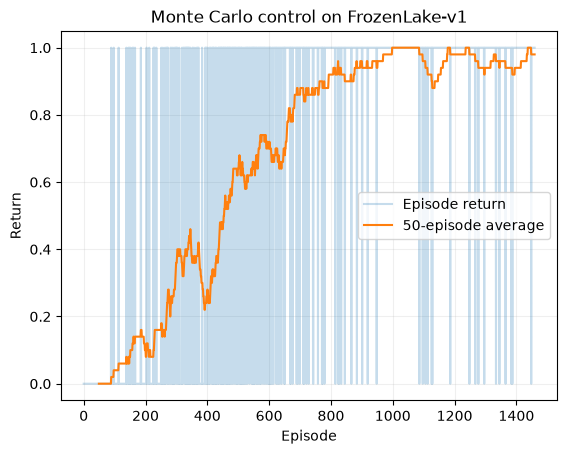

In [4]:
window = min(50, len(episode_returns))
moving_average = np.convolve(episode_returns, np.ones(window) / window, mode="valid")
plt.plot(episode_returns, alpha=0.25, label="Episode return")
plt.plot(np.arange(window - 1, len(episode_returns)), moving_average, label=f"{window}-episode average")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.title("Monte Carlo control on FrozenLake-v1")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 4. Evaluate the greedy policy

This opens a separate rendered environment and disables exploration for 5 episodes.

In [5]:
evaluation_env = gym.make(ENV_ID, render_mode="human", is_slippery=False)
evaluation_returns = []
try:
    for episode in range(5):
        state, _ = evaluation_env.reset(seed=10 + episode)
        total_reward = 0.0
        done = False
        while not done:
            action = select_action(state, TOTAL_TIMESTEPS, deterministic=True)
            state, reward, terminated, truncated, _ = evaluation_env.step(action)
            total_reward += reward
            done = terminated or truncated
        evaluation_returns.append(total_reward)
finally:
    evaluation_env.close()
print("Episode returns:", evaluation_returns)

Episode returns: [1.0, 1.0, 1.0, 1.0, 1.0]
